# Discovering Hidden Signals in Global News That Precede Oil Price Movements

## v7 Final — 100-Run Ensemble

**Changes from v5**: 100 independent training runs (up from 60) + ensemble prediction (averaged output of all 100 models)

## 0. Setup

In [26]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch yfinance tqdm

In [27]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

## 1. Brent Crude Weekly Prices

The code uses yf.download('BZ=F', ...) to pull Brent crude futures data from Yahoo Finance, covering January 2015 through March 2025 at a weekly interval. It then cleans up the column names, keeping only the closing price (renamed to brent_close). A new column brent_return is calculated using .pct_change(), which gives the week-over-week percentage return. The date index is converted to weekly periods for cleaner plotting, and any rows with missing data are dropped.

The print line confirms the dataset: 530 weeks of data from 2015-01-05 to 2025-03-02.

The code creates two vertically stacked subplots sharing the same x-axis:

The top chart is a line plot of the weekly closing price in dollars. The bottom chart is a bar plot of weekly returns. Positive weeks are shown in teal/green (#0CA678) and negative weeks in orange/red (#E8590C). The gray horizontal line at zero is a visual reference. 

There is a massive negative spike around 2020 (the COVID crash produced returns of roughly −20% to −30% in a single week), plus some notable volatility clusters in 2022. Most weeks show modest returns within ±5%.

[*********************100%***********************]  1 of 1 completed


Brent: 583 weeks, 2015-01-05 to 2026-03-02


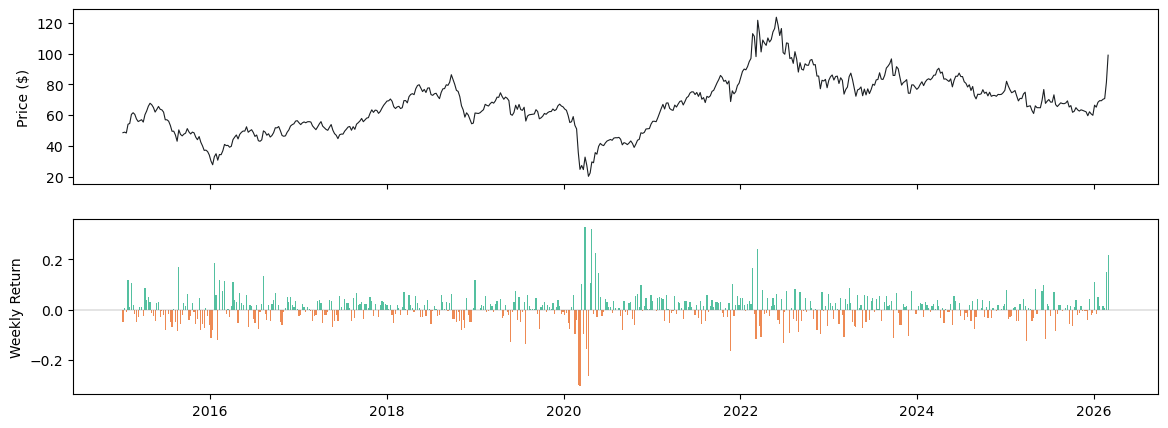

In [28]:
import yfinance as yf

brent = yf.download('BZ=F', start='2015-01-01', end='2026-03-09', interval='1wk')
brent.columns = brent.columns.get_level_values(0) 
brent = brent[['Close']].rename(columns={'Close': 'brent_close'})
brent['brent_return'] = brent['brent_close'].pct_change()
brent['week'] = brent.index.to_period('W').start_time
brent = brent.dropna().reset_index(drop=True)

print(f'Brent: {len(brent)} weeks, {brent["week"].min().date()} to {brent["week"].max().date()}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(brent['week'], brent['brent_close'], color='#1B1F23', linewidth=0.8)
ax1.set_ylabel('Price ($)')
ax2.bar(brent['week'], brent['brent_return'],
        color=np.where(brent['brent_return']>0, '#0CA678', '#E8590C'), width=5, alpha=0.7)
ax2.set_ylabel('Weekly Return')
ax2.axhline(0, color='gray', linewidth=0.3)
plt.show()

## 2. BigQuery Query

104 theme filters, Ran at [console.cloud.google.com/bigquery](https://console.cloud.google.com/bigquery)

```sql
WITH gcam_parsed AS (
  SELECT
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)), WEEK) AS week,
    SPLIT(pair, ':')[OFFSET(0)] AS dim,
    SAFE_CAST(SPLIT(pair, ':')[OFFSET(1)] AS FLOAT64) AS score
  FROM `gdelt-bq.gdeltv2.gkg_partitioned`,
    UNNEST(SPLIT(GCAM, ',')) AS pair
  WHERE DATE(_PARTITIONTIME) BETWEEN '2015-01-01' AND '2026-03-09'
    AND (
      V2Themes LIKE '%ENV_OIL%'
      OR V2Themes LIKE '%ECON_OILPRICE%'
      OR V2Themes LIKE '%ECON_PRICE_CRUDE%'
      OR V2Themes LIKE '%OPEC%'
      OR V2Themes LIKE '%TAX_PETROLEUM%'
      OR V2Themes LIKE '%WB_2637_OIL_AND_GAS%'
      OR V2Themes LIKE '%EPU_CATS_ENERGY%'
      OR V2Themes LIKE '%ENV_GAS%'
      OR V2Themes LIKE '%ENV_COAL%'
      OR V2Themes LIKE '%ENV_NUCLEAR%'
      OR V2Themes LIKE '%ENV_SOLAR%'
      OR V2Themes LIKE '%ENV_WIND%'
      OR V2Themes LIKE '%ENV_MINING%'
      OR V2Themes LIKE '%ENV_NATURALGAS%'
      OR V2Themes LIKE '%ECON_PRICE_METALS%'
      OR V2Themes LIKE '%ECON_PRICE_FOOD%'
      OR V2Themes LIKE '%ARMED_CONFLICT%'
      OR V2Themes LIKE '%ARMEDCONFLICT%'
      OR V2Themes LIKE '%CIVIL_WAR%'
      OR V2Themes LIKE '%MILITARY%'
      OR V2Themes LIKE '%TERROR%'
      OR V2Themes LIKE '%REBELLION%'
      OR V2Themes LIKE '%INSURGENCY%'
      OR V2Themes LIKE '%CEASEFIRE%'
      OR V2Themes LIKE '%PEACEKEEPING%'
      OR V2Themes LIKE '%COUP%'
      OR V2Themes LIKE '%ASSASSINATION%'
      OR V2Themes LIKE '%POLITICAL_VIOLENCE%'
      OR V2Themes LIKE '%ARMS_DEAL%'
      OR V2Themes LIKE '%ARMS_EMBARGO%'
      OR V2Themes LIKE '%WMD%'
      OR V2Themes LIKE '%MISSILE%'
      OR V2Themes LIKE '%DRONE_STRIKE%'
      OR V2Themes LIKE '%AIRSTRIKE%'
      OR V2Themes LIKE '%BLOCKADE%'
      OR V2Themes LIKE '%MARITIME_INCIDENT%'
      OR V2Themes LIKE '%PIRACY%'
      OR V2Themes LIKE '%SANCTION%'
      OR V2Themes LIKE '%EMBARGO%'
      OR V2Themes LIKE '%DIPLOMACY%'
      OR V2Themes LIKE '%ALLIANCE%'
      OR V2Themes LIKE '%TREATY%'
      OR V2Themes LIKE '%SUMMIT%'
      OR V2Themes LIKE '%NEGOTIATE%'
      OR V2Themes LIKE '%FOREIGN_POLICY%'
      OR V2Themes LIKE '%REGIME_CHANGE%'
      OR V2Themes LIKE '%ECON_BANKRUPTCY%'
      OR V2Themes LIKE '%ECON_STOCKMARKET%'
      OR V2Themes LIKE '%ECON_TRADE%'
      OR V2Themes LIKE '%ECON_INFLATION%'
      OR V2Themes LIKE '%ECON_DEBT%'
      OR V2Themes LIKE '%ECON_CURRENCY%'
      OR V2Themes LIKE '%ECON_INTEREST_RATE%'
      OR V2Themes LIKE '%ECON_RECESSION%'
      OR V2Themes LIKE '%ECON_GDP%'
      OR V2Themes LIKE '%ECON_UNEMPLOYMENT%'
      OR V2Themes LIKE '%ECON_HOUSING%'
      OR V2Themes LIKE '%ECON_COST_OF_LIVING%'
      OR V2Themes LIKE '%ECON_BUBBLE%'
      OR V2Themes LIKE '%CENTRAL_BANK%'
      OR V2Themes LIKE '%FEDERAL_RESERVE%'
      OR V2Themes LIKE '%TARIFF%'
      OR V2Themes LIKE '%TRADE_WAR%'
      OR V2Themes LIKE '%SUBSIDY%'
      OR V2Themes LIKE '%SHIPPING%'
      OR V2Themes LIKE '%MARITIME%'
      OR V2Themes LIKE '%PIPELINE%'
      OR V2Themes LIKE '%INFRASTRUCTURE%'
      OR V2Themes LIKE '%TRANSPORTATION%'
      OR V2Themes LIKE '%SUPPLY_CHAIN%'
      OR V2Themes LIKE '%LOGISTICS%'
      OR V2Themes LIKE '%ELECTION%'
      OR V2Themes LIKE '%PROTEST%'
      OR V2Themes LIKE '%DEMONSTRATION%'
      OR V2Themes LIKE '%RIOT%'
      OR V2Themes LIKE '%CORRUPTION%'
      OR V2Themes LIKE '%IMPEACH%'
      OR V2Themes LIKE '%NATURAL_DISASTER%'
      OR V2Themes LIKE '%EARTHQUAKE%'
      OR V2Themes LIKE '%HURRICANE%'
      OR V2Themes LIKE '%FLOOD%'
      OR V2Themes LIKE '%DROUGHT%'
      OR V2Themes LIKE '%WILDFIRE%'
      OR V2Themes LIKE '%ENV_CLIMATECHANGE%'
      OR V2Themes LIKE '%CARBON%'
      OR V2Themes LIKE '%EMISSIONS%'
      OR V2Themes LIKE '%PANDEMIC%'
      OR V2Themes LIKE '%HEALTH_PANDEMIC%'
      OR V2Themes LIKE '%EPIDEMIC%'
      OR V2Themes LIKE '%REFUGEE%'
      OR V2Themes LIKE '%FAMINE%'
      OR V2Themes LIKE '%FOOD_SECURITY%'
      OR V2Themes LIKE '%CYBER_ATTACK%'
      OR V2Themes LIKE '%CYBER_SECURITY%'
      OR V2Themes LIKE '%MIDDLEEAST%'
      OR V2Themes LIKE '%BRICS%'
      OR V2Themes LIKE '%CHINA_BELT_AND_ROAD%'
      OR V2Themes LIKE '%ARCTIC%'
      OR V2Themes LIKE '%EPU_CATS_FISCAL_POLICY%'
      OR V2Themes LIKE '%EPU_CATS_MONETARY_POLICY%'
      OR V2Themes LIKE '%EPU_CATS_TRADE_POLICY%'
      OR V2Themes LIKE '%EPU_CATS_REGULATION%'
      OR V2Themes LIKE '%EPU_CATS_NATIONAL_SECURITY%'
      OR V2Themes LIKE '%EPU_CATS_SOVEREIGN_DEBT%'
      OR V2Themes LIKE '%RESIGNATION%'
      OR V2Themes LIKE '%APPOINTMENT%'
      OR V2Themes LIKE '%MERGER%'
      OR V2Themes LIKE '%ACQUISITION%'
      OR V2Themes LIKE '%PERMIT%'
      OR V2Themes LIKE '%LICENSE%'
      OR V2Themes LIKE '%CARTEL%'
      OR V2Themes LIKE '%ORGANIZED_CRIME%'
      OR V2Themes LIKE '%LOBBYING%'
      OR V2Themes LIKE '%TAX_EVASION%'
      OR V2Themes LIKE '%DISINFORMATION%'
    )
    AND GCAM IS NOT NULL
    AND GCAM != ''
)
SELECT
  week,
  dim,
  AVG(score) AS score_mean,
  COUNT(*) AS n_articles
FROM gcam_parsed
WHERE dim IS NOT NULL AND score IS NOT NULL
GROUP BY week, dim
ORDER BY week, dim
```

Saved as `./data/gdelt_gcam_weekly.csv`

## Step 3 — Load GCAM Data (mean only)

In [29]:
gcam_raw = pd.read_csv('./data/gdelt_gcam_weekly.csv')
gcam_raw['week'] = pd.to_datetime(gcam_raw['week'])

print(f'Raw: {gcam_raw.shape}')
print(f'Unique dims: {gcam_raw["dim"].nunique()}')
print(f'Weeks: {gcam_raw["week"].nunique()}')

Raw: (1673567, 4)
Unique dims: 2962
Weeks: 576


In [30]:
# Load GCAM Codebook (for human-readable names later)
import urllib.request

url = 'http://data.gdeltproject.org/documentation/GCAM-MASTER-CODEBOOK.TXT'
response = urllib.request.urlopen(url)
raw = response.read().decode('utf-8', errors='ignore')

codebook = {}
for line in raw.strip().split('\n')[1:]:
    parts = line.split('\t')
    if len(parts) >= 7:
        codebook[parts[0]] = {'dictionary': parts[5], 'dimension': parts[6]}

print(f'Codebook loaded: {len(codebook)} dimensions')

Codebook loaded: 2989 dimensions


In [31]:
sample = gcam_raw.sample(5)
sample

,week,dim,score_mean,n_articles
677828,2019-09-08,c15.55,1.639480,122842
1151612,2022-10-09,c15.114,1.261678,52576
1517100,2025-02-16,v19.8,5.235565,1477173
938955,2021-05-16,c9.561,3.594330,845113
1335627,2023-12-17,c31.3,1.548682,986


In [32]:
for _, row in sample.iterrows():
    dim = row['dim']
    if dim in codebook:
        info = codebook[dim]
        label = f"{info['dictionary']} → {info['dimension']}"
    else:
        label = '(not in codebook)'
    print(f"{dim:10s} score={row['score_mean']:.3f}  articles={row['n_articles']:>10,}  {label}")

c15.55     score=1.639  articles=   122,842  WordNet Affect 1.1 → complacency
c15.114    score=1.262  articles=    52,576  WordNet Affect 1.1 → fidget
v19.8      score=5.236  articles= 1,477,173  Affective Norms for English Words (ANEW) 2010 → Arousal (Women) (Scored Value)
c9.561     score=3.594  articles=   845,113  Roget's Thesaurus 1911 Edition → CLASS IV - INTELLECTUAL FACULTIES/4.2 COMMUNICATION OF IDEAS/4.2.2 MODES OF COMMUNICATION/561 NEGATION
c31.3      score=1.549  articles=       986  Regressive Imagery Dictionary Swedish Edition → EMOTION/AXIETY


In [33]:
dim_totals = gcam_raw.groupby('dim')['n_articles'].sum().sort_values(ascending=False)
top_dim = dim_totals.index[0]

total_weeks = gcam_raw['week'].nunique()
appeared_weeks = gcam_raw[gcam_raw['dim'] == top_dim]['week'].nunique()
missing_weeks = total_weeks - appeared_weeks

approx_articles = dim_totals.iloc[0]

print(f'Approximate total articles: {approx_articles:,.0f}')

Most universal dimension: wc
Appeared in 576 / 576 weeks (missing: 0)
Approximate total articles: 1,056,029,354


In [34]:
# Pivot: long → wide (mean only, no std)
gcam_wide = gcam_raw.pivot_table(index='week', columns='dim', values='score_mean', fill_value=0)

# Article count per week
article_counts = gcam_raw.groupby('week')['n_articles'].sum().to_frame('total_articles')

features = gcam_wide.join(article_counts).reset_index()
features = features.fillna(0).sort_values('week').reset_index(drop=True)

# Save original GCAM column names for later reverse-mapping
gcam_dim_names = list(gcam_wide.columns)

print(f'Feature matrix: {features.shape[0]} weeks × {len(gcam_dim_names)} GCAM dims + 1 article count')
print(f'Total features: {features.shape[1] - 1}')  # minus week

Feature matrix: 576 weeks × 2962 GCAM dims + 1 article count
Total features: 2963


## 3. Build Dataset + PCA Dimensionality Reduction

2,300 features with ~300 training samples equals guaranteed overfitting.

PCA reduces to 100 components while preserving the ability to **reverse-map** back to original GCAM dimensions. The `pca.components_` matrix tells us exactly which raw dimensions contribute to each PC.

In [35]:
# Merge with price
features['week'] = features['week'].dt.to_period('W-SAT').dt.start_time
brent['week'] = brent['week'].dt.to_period('W-SAT').dt.start_time
dataset = features.merge(brent[['week', 'brent_close', 'brent_return']], on='week', how='inner')
dataset = dataset.sort_values('week').reset_index(drop=True)

# ── Extreme value clipping ──
CLIP = 0.10
n_clipped = ((dataset['brent_return'] < -CLIP) | (dataset['brent_return'] > CLIP)).sum()
dataset['brent_return'] = dataset['brent_return'].clip(-CLIP, CLIP)
print(f'Clipped {n_clipped} extreme returns to ±{CLIP:.0%}')

# ── Market features ──
dataset['ret_lag1'] = dataset['brent_return'].shift(1)
dataset['ret_lag2'] = dataset['brent_return'].shift(2)
dataset['volatility_4w'] = dataset['brent_return'].rolling(4).std()

# S&P 500
sp500 = yf.download('^GSPC', start='2015-01-01', end='2026-03-09', interval='1wk')
sp500.columns = sp500.columns.get_level_values(0)
sp500['sp500_return'] = sp500['Close'].pct_change()
sp500['week'] = sp500.index.to_period('W').start_time
sp500['week'] = sp500['week'].dt.to_period('W-SAT').dt.start_time
sp500 = sp500[['week', 'sp500_return']].dropna()

# Dollar Index
dxy = yf.download('DX-Y.NYB', start='2015-01-01', end='2026-03-09', interval='1wk')
dxy.columns = dxy.columns.get_level_values(0)
dxy['dxy_return'] = dxy['Close'].pct_change()
dxy['week'] = dxy.index.to_period('W').start_time
dxy['week'] = dxy['week'].dt.to_period('W-SAT').dt.start_time
dxy = dxy[['week', 'dxy_return']].dropna()

# VIX (Market Fear Index)
vix = yf.download('^VIX', start='2015-01-01', end='2026-03-09', interval='1wk')
vix.columns = vix.columns.get_level_values(0)
vix['vix_level'] = vix['Close']
vix['week'] = vix.index.to_period('W').start_time
vix['week'] = vix['week'].dt.to_period('W-SAT').dt.start_time
vix = vix[['week', 'vix_level']].dropna()

# Merge market data
dataset = dataset.merge(sp500, on='week', how='left')
dataset = dataset.merge(dxy, on='week', how='left')
dataset = dataset.merge(vix, on='week', how='left')

# Fill NaN: 0 for returns, median for VIX level
dataset['sp500_return'] = dataset['sp500_return'].fillna(0)
dataset['dxy_return'] = dataset['dxy_return'].fillna(0)
dataset['vix_level'] = dataset['vix_level'].fillna(dataset['vix_level'].median())
dataset = dataset.dropna().reset_index(drop=True)

# Separate GCAM features vs market features
non_feature_cols = ['week', 'brent_close', 'brent_return',
                    'ret_lag1', 'ret_lag2', 'volatility_4w', 'sp500_return', 'dxy_return', 'vix_level']
feature_cols = [c for c in dataset.columns if c not in non_feature_cols]
market_cols = ['ret_lag1', 'ret_lag2', 'volatility_4w', 'sp500_return', 'dxy_return', 'vix_level']

print(f'Dataset: {len(dataset)} weeks × {len(feature_cols)} GCAM features + {len(market_cols)} market features')
print(f'Market features: {market_cols}')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Clipped 35 extreme returns to ±10%
Dataset: 572 weeks × 2963 GCAM features + 6 market features
Market features: ['ret_lag1', 'ret_lag2', 'volatility_4w', 'sp500_return', 'dxy_return', 'vix_level']


In [36]:
# Normalize (fit on train only)
from sklearn.preprocessing import StandardScaler

train_mask = dataset['week'] < pd.Timestamp('2023-01-01')

# GCAM features
scaler = StandardScaler()
scaler.fit(dataset.loc[train_mask, feature_cols])
X_scaled = np.nan_to_num(scaler.transform(dataset[feature_cols]), nan=0.0, posinf=0.0, neginf=0.0)

# Market features (separate scaler)
market_scaler = StandardScaler()
market_scaler.fit(dataset.loc[train_mask, market_cols])
X_market = np.nan_to_num(market_scaler.transform(dataset[market_cols]), nan=0.0, posinf=0.0, neginf=0.0)

print(f'GCAM scaled: {X_scaled.shape}')
print(f'Market scaled: {X_market.shape}')

GCAM scaled: (572, 2963)
Market scaled: (572, 6)


PCA: 2963 → 100 components
Explained variance: 88.3%
Loading matrix saved: (2963, 100) (raw_features × PCs)

Combined: (572, 106) (PCA 100 + Market 6)


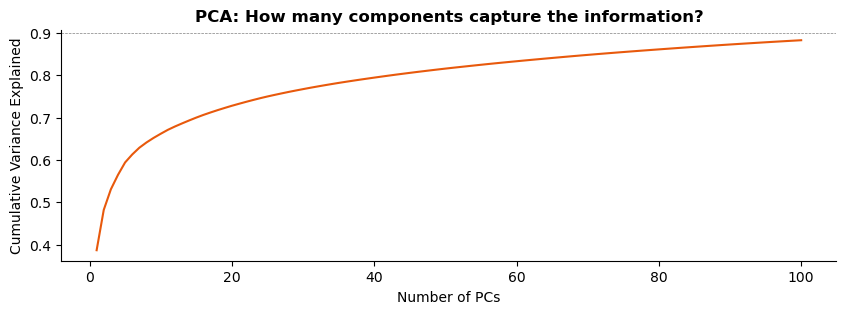

In [38]:
# ═══════════════════════════════════════════════════════
# PCA: 2,300 → 100 dimensions (fit on train only)
# ═══════════════════════════════════════════════════════
from sklearn.decomposition import PCA

N_COMPONENTS = 100
te = dataset[dataset['week'] < pd.Timestamp('2023-01-01')].index[-1]

pca = PCA(n_components=N_COMPONENTS)
pca.fit(X_scaled[:te+1])  # train only
X_pca = pca.transform(X_scaled)  # apply to all

explained = pca.explained_variance_ratio_.sum()
print(f'PCA: {X_scaled.shape[1]} → {N_COMPONENTS} components')
print(f'Explained variance: {explained:.1%}')

# Save the loading matrix for reverse-mapping later
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f'PC{i}' for i in range(N_COMPONENTS)]
)
print(f'Loading matrix saved: {pca_loadings.shape} (raw_features × PCs)')

# ── Combine PCA + Market features ──
X_combined = np.hstack([X_pca, X_market])  # (weeks, 100+5=105)
N_MARKET = X_market.shape[1]
print(f'\nCombined: {X_combined.shape} (PCA {N_COMPONENTS} + Market {N_MARKET})')

# Variance explained plot
fig, ax = plt.subplots(figsize=(10, 3))
cum_var = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, N_COMPONENTS+1), cum_var, color='#E8590C', linewidth=1.5)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Number of PCs'); ax.set_ylabel('Cumulative Variance Explained')
ax.set_title('PCA: How many components capture the information?', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.show()

In [39]:
# Sliding windows (using PCA + Market features)
import torch
from torch.utils.data import Dataset, DataLoader

LOOKBACK = 8

class SeqDataset(Dataset):
    def __init__(self, X, y, lb=8):
        self.X, self.y, self.lb = torch.FloatTensor(X), torch.FloatTensor(y), lb
    def __len__(self): return len(self.X) - self.lb
    def __getitem__(self, i): return self.X[i:i+self.lb], self.y[i+self.lb]

y_all = dataset['brent_return'].values
weeks_all = dataset['week'].values

ve = dataset[dataset['week'] < pd.Timestamp('2024-01-01')].index[-1]

train_dl = DataLoader(SeqDataset(X_combined[:te+1], y_all[:te+1], LOOKBACK), batch_size=32, shuffle=True)
val_dl = DataLoader(SeqDataset(X_combined[te-LOOKBACK:ve+1], y_all[te-LOOKBACK:ve+1], LOOKBACK), batch_size=32)
test_dl = DataLoader(SeqDataset(X_combined[ve-LOOKBACK:], y_all[ve-LOOKBACK:], LOOKBACK), batch_size=32)

n_features = X_combined.shape[1]  # 105 (100 PCA + 5 market)
print(f'Model input: {n_features} features ({N_COMPONENTS} PCA + {N_MARKET} market) × {LOOKBACK} weeks')
print(f'Train: {len(train_dl.dataset)} | Val: {len(val_dl.dataset)} | Test: {len(test_dl.dataset)}')

Model input: 106 features (100 PCA + 6 market) × 8 weeks
Train: 400 | Val: 54 | Test: 112


## 4. Temporal Transformer

In [40]:
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * -(math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class OilSignalNet(nn.Module):
    def __init__(self, n_feat, d_model=64, n_heads=4, n_layers=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(n_feat, d_model), nn.GELU(), nn.Dropout(dropout))
        self.pos = PositionalEncoding(d_model)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2,
                                       dropout=dropout, batch_first=True, activation='gelu'),
            num_layers=n_layers
        )
        self.head = nn.Sequential(nn.Linear(d_model, 32), nn.GELU(), nn.Dropout(dropout), nn.Linear(32, 1))
    
    def forward(self, x):
        h = self.pos(self.encoder(x))
        h = self.transformer(h)
        return self.head(h[:, -1, :]).squeeze(-1)

model = OilSignalNet(n_features, d_model=64)
print(f'OilSignalNet: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Input: ({LOOKBACK} weeks × {n_features} PCs) → 1 prediction')

OilSignalNet: 75,905 params
Input: (8 weeks × 106 PCs) → 1 prediction


## 5. Multi-Run Training & Discovery (100 runs)

Instead of a single training run, we repeat the full pipeline 100 times with different random seeds. This provides:
1. Statistical robustness — confidence intervals on all metrics
2. Dimension stability ranking — which GCAM features appear consistently
3. Ensemble prediction — averaged predictions across all 100 models

In [41]:
from sklearn.metrics import mean_squared_error, r2_score
from collections import Counter, defaultdict
import random

device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

N_RUNS = 100
all_metrics = []
all_top30 = []
all_models = []
all_run_preds = []   # NEW: store per-run test predictions for ensemble

# Pre-collect test data (doesn't change across runs)
X_test_chunks = []
with torch.no_grad():
    for xb, yb in test_dl:
        X_test_chunks.append(xb)
X_test_t = torch.cat(X_test_chunks)

# Also pre-collect true labels
true_labels = []
for xb, yb in test_dl:
    true_labels.extend(yb.numpy())
true_labels = np.array(true_labels)

# Feature names: PC0-99 for GCAM PCA, then market names
all_feature_names = [f'PC{i}' for i in range(N_COMPONENTS)] + market_cols

for run in range(N_RUNS):
    print(f'\n{"═"*50}')
    print(f'RUN {run+1}/{N_RUNS}')
    print(f'{"═"*50}')
    
    # ── Train ──
    model = OilSignalNet(n_features, d_model=64).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.HuberLoss(delta=0.05)
    best_val, best_state, no_improve = float('inf'), None, 0
    
    for epoch in range(150):
        model.train()
        tl = []
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl = np.mean([criterion(model(xb.to(device)), yb.to(device)).item()
                          for xb, yb in val_dl])
        scheduler.step(vl)
        if vl < best_val:
            best_val = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= 15:
            break
    
    model.load_state_dict(best_state); model = model.to(device); model.eval()
    print(f'  Trained: {epoch+1} epochs, best val={best_val:.6f}')
    
    # ── Test metrics ──
    preds_run, true_run = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds_run.extend(model(xb.to(device)).cpu().numpy())
            true_run.extend(yb.numpy())
    preds_run, true_run = np.array(preds_run), np.array(true_run)
    
    rmse = np.sqrt(mean_squared_error(true_run, preds_run))
    r2 = r2_score(true_run, preds_run)
    corr = np.corrcoef(preds_run, true_run)[0, 1]
    da = np.mean(np.sign(preds_run) == np.sign(true_run))
    all_metrics.append({'run': run+1, 'rmse': rmse, 'r2': r2, 'corr': corr, 'dir_acc': da})
    all_run_preds.append(preds_run)  # NEW: save predictions
    print(f'  R²={r2:.4f} | Corr={corr:.4f} | Dir.Acc={da:.1%}')
    
    # ── Permutation importance ──
    base_mse = mean_squared_error(true_run, preds_run)
    feat_importances = {}
    for fi in range(n_features):
        degs = []
        for _ in range(3):
            Xp = X_test_t.clone()
            Xp[:, :, fi] = Xp[torch.randperm(Xp.size(0)), :, fi]
            with torch.no_grad():
                pp = model(Xp.to(device)).cpu().numpy()
            degs.append(mean_squared_error(true_run, pp) - base_mse)
        feat_importances[all_feature_names[fi]] = np.mean(degs)
    
    # ── Reverse map: PCA components only (skip market features) ──
    pca_imps = {k: v for k, v in feat_importances.items() if k.startswith('PC')}
    pca_imp_sorted = sorted(pca_imps.items(), key=lambda x: -x[1])[:20]
    
    gcam_importance = np.zeros(len(feature_cols))
    for pc_name, pc_imp_val in pca_imp_sorted:
        pc_idx = int(pc_name.replace('PC', ''))
        pc_imp_val = max(pc_imp_val, 0)
        loadings = np.abs(pca.components_[pc_idx])
        gcam_importance += loadings * pc_imp_val
    
    gcam_imp_run = pd.DataFrame({
        'gcam_dimension': feature_cols, 'importance': gcam_importance
    }).sort_values('importance', ascending=False)
    
    all_top30.append(gcam_imp_run.head(30)['gcam_dimension'].tolist())
    all_models.append(best_state)

print(f'\n{"═"*50}')
print(f'ALL {N_RUNS} RUNS COMPLETE')
print(f'{"═"*50}')


Device: mps

══════════════════════════════════════════════════
RUN 1/100
══════════════════════════════════════════════════
  Trained: 26 epochs, best val=0.000997
  R²=-0.0125 | Corr=0.1458 | Dir.Acc=52.7%

══════════════════════════════════════════════════
RUN 2/100
══════════════════════════════════════════════════
  Trained: 34 epochs, best val=0.000976
  R²=0.0067 | Corr=0.0855 | Dir.Acc=52.7%

══════════════════════════════════════════════════
RUN 3/100
══════════════════════════════════════════════════
  Trained: 41 epochs, best val=0.001004
  R²=-0.0650 | Corr=0.0336 | Dir.Acc=51.8%

══════════════════════════════════════════════════
RUN 4/100
══════════════════════════════════════════════════
  Trained: 25 epochs, best val=0.000986
  R²=-0.2225 | Corr=0.0817 | Dir.Acc=53.6%

══════════════════════════════════════════════════
RUN 5/100
══════════════════════════════════════════════════
  Trained: 31 epochs, best val=0.000963
  R²=-0.1702 | Corr=0.0409 | Dir.Acc=52.7%

════════

## 6. Aggregated Results (100 runs)

In [42]:
# Metrics Summary
r2s = [m['r2'] for m in all_metrics]
das = [m['dir_acc'] for m in all_metrics]
corrs = [m['corr'] for m in all_metrics]
rmses = [m['rmse'] for m in all_metrics]

print(f'METRICS ACROSS {N_RUNS} RUNS')
print('═' * 55)
print(f'{"Run":>4s} {"RMSE":>8s} {"R²":>9s} {"Corr":>9s} {"Dir.Acc":>9s}')
print('-' * 55)
for m in all_metrics:
    print(f'{m["run"]:>4d} {m["rmse"]:>8.5f} {m["r2"]:>9.4f} {m["corr"]:>9.4f} {m["dir_acc"]:>8.1%}')
print('-' * 55)
print(f'{"Mean":>4s} {np.mean(rmses):>8.5f} {np.mean(r2s):>9.4f} {np.mean(corrs):>9.4f} {np.mean(das):>8.1%}')
print(f'{"Std":>4s} {np.std(rmses):>8.5f} {np.std(r2s):>9.4f} {np.std(corrs):>9.4f} {np.std(das):>8.1%}')
print(f'\nFor presentation:')
print(f'  R²      = {np.mean(r2s):.3f} ± {np.std(r2s):.3f}')
print(f'  Corr    = {np.mean(corrs):.3f} ± {np.std(corrs):.3f}')
print(f'  Dir.Acc = {np.mean(das):.1%} ± {np.std(das):.1%}')


METRICS ACROSS 100 RUNS
═══════════════════════════════════════════════════════
 Run     RMSE        R²      Corr   Dir.Acc
-------------------------------------------------------
   1  0.03736   -0.0125    0.1458    52.7%
   2  0.03700    0.0067    0.0855    52.7%
   3  0.03831   -0.0650    0.0336    51.8%
   4  0.04105   -0.2225    0.0817    53.6%
   5  0.04016   -0.1702    0.0409    52.7%
   6  0.03988   -0.1538   -0.1681    44.6%
   7  0.03665    0.0257    0.1885    55.4%
   8  0.03835   -0.0670    0.0156    56.2%
   9  0.03900   -0.1035    0.0892    54.5%
  10  0.03730   -0.0095   -0.0034    52.7%
  11  0.03711    0.0011    0.1745    53.6%
  12  0.03887   -0.0963   -0.0397    50.0%
  13  0.03892   -0.0991   -0.1680    48.2%
  14  0.03645    0.0359    0.2166    54.5%
  15  0.03854   -0.0775    0.0872    53.6%
  16  0.03685    0.0149    0.1331    52.7%
  17  0.03827   -0.0623   -0.0881    45.5%
  18  0.03864   -0.0834    0.1544    53.6%
  19  0.03754   -0.0223    0.1105    53.6%
  2

In [43]:
# Most Stable GCAM Dimensions 
dim_counts = Counter()
dim_positions = defaultdict(list)
for dims in all_top30:
    for pos, dim in enumerate(dims, 1):
        dim_counts[dim] += 1
        dim_positions[dim].append(pos)

dim_list = [(dim, count, np.mean(dim_positions[dim])) for dim, count in dim_counts.items()]
dim_list.sort(key=lambda x: (-x[1], x[2]))

print(f'MOST STABLE GCAM DIMENSIONS (across {N_RUNS} runs)')
print('═' * 100)
print(f'{"Rank":>4s} {"Dimension":>12s} {"Freq":>8s} {"AvgPos":>7s}  {"Dictionary → Meaning"}')
print('-' * 100)
for rank, (dim, count, avg_pos) in enumerate(dim_list[:30], 1):
    freq_bar = '█' * count
    if dim in codebook:
        info = codebook[dim]
        label = f"{info['dictionary']} → {info['dimension']}"
    else:
        label = '(not in codebook)'
    print(f'{rank:>4d} {dim:>12s} {count:>3d}/{N_RUNS} {avg_pos:>6.1f}  {freq_bar:12s} {label}')

MOST STABLE GCAM DIMENSIONS (across 100 runs)
════════════════════════════════════════════════════════════════════════════════════════════════════
Rank    Dimension     Freq  AvgPos  Dictionary → Meaning
----------------------------------------------------------------------------------------------------
   1        c4.28  35/100   12.3  ███████████████████████████████████ Lexicoder Topic Dictionaries → RELIGION
   2       c18.71  32/100   10.3  ████████████████████████████████ GDELT GKG Themes → SECURITY_SERVICES
   3       v23.25  30/100   12.2  ██████████████████████████████ ML-SENTICON (Non-English) → Level5Positive (Scored Value)
   4      c9.1007  29/100   13.4  █████████████████████████████ Roget's Thesaurus 1911 Edition → CLASS VI - SENTIMENT AND MORAL POWERS/6.4 MORAL AFFECTIONS/6.4.5 INSTITUTIONS/1007 JURISDICTION
   5       v23.23  28/100   11.0  ████████████████████████████ ML-SENTICON (Non-English) → Level4Positive (Scored Value)
   6        c8.19  28/100   11.5  ██████████

In [45]:
# Dictionary Family Breakdown

# Build family_map: GCAM prefix → dictionary family name
family_map = {}
for dim_code, info in codebook.items():
    prefix = dim_code.split('.')[0]
    if prefix not in family_map:
        family_map[prefix] = info['dictionary']

print(f'Family map: {len(family_map)} prefixes → {len(set(family_map.values()))} dictionary families')

family_counts_per_run = defaultdict(list)
for dims in all_top30:
    run_family = Counter()
    for dim in dims:
        prefix = dim.split('.')[0]
        run_family[family_map.get(prefix, 'Other')] += 1
    for fam in set(family_map.values()):
        family_counts_per_run[fam].append(run_family.get(fam, 0))

print(f'DICTIONARY FAMILY (avg count in Top 30, across {N_RUNS} runs)')
print('═' * 55)
print(f'{"Dictionary":>30s} {"Mean":>6s} {"Min":>4s} {"Max":>4s}')
print('-' * 55)
fam_sorted2 = sorted(family_counts_per_run.items(), key=lambda x: -np.mean(x[1]))
for fam, counts in fam_sorted2:
    if np.mean(counts) > 0:
        print(f'{fam:>30s} {np.mean(counts):>5.1f} {np.min(counts):>4d} {np.max(counts):>4d}')

Family map: 51 prefixes → 41 dictionary families
DICTIONARY FAMILY (avg count in Top 30, across 100 runs)
═══════════════════════════════════════════════════════
                    Dictionary   Mean  Min  Max
-------------------------------------------------------
            WordNet Affect 1.1   7.7    2   18
Roget's Thesaurus 1911 Edition   6.6    1   14
              GDELT GKG Themes   6.0    0   16
     ML-SENTICON (Non-English)   5.7    0   17
General Inquirer V1.02 (IV-4 Harvard Psychosocial Dictionary / NamenWirth & Weber's Lasswell Dictionary)   1.1    0    5
  Lexicoder Topic Dictionaries   0.8    0    2
 Regressive Imagery Dictionary   0.5    0    2
Linguistic Inquiry and Word Count (LIWC)   0.3    0    2
           WordNet Domains 3.2   0.3    0    2
Spanish Adaptation of Affective Norms for English Words (Spanish ANEW)   0.2    0   10
     Hedonometer (Non-English)   0.2    0    2
Affective Norms for English Words (ANEW) 2010   0.2    0    2
                 Forest Values 

## 6.5 Ensemble Prediction (100-Model Average)

Average the predictions of all 100 independently trained models. Ensemble averaging cancels out per-run noise while preserving any consistent signal.

ENSEMBLE PREDICTION (average of all 100 models)
═══════════════════════════════════════════════════════
  RMSE      = 0.03710
  R²        = 0.0015
  Corr      = 0.1777
  Dir.Acc   = 52.7%

COMPARISON: Ensemble vs Individual Runs
═══════════════════════════════════════════════════════
               Ensemble   Ind.Mean   Ind.Best
-------------------------------------------------------
        RMSE    0.03710    0.03851    0.03645
          R²     0.0015    -0.0776     0.0359
        Corr     0.1777     0.0468     0.2411
     Dir.Acc      52.7%      51.9%      59.8%



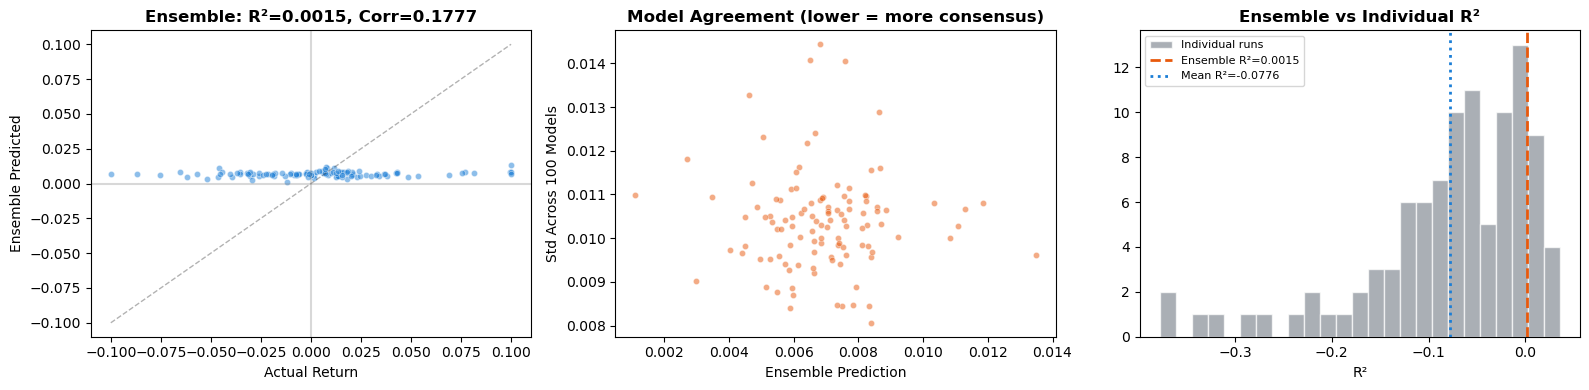

HIGH-CONFIDENCE SUBSET (top 50% model agreement: 56 weeks)
  R²      = -0.0272
  Corr    = 0.2081
  Dir.Acc = 55.4%


In [46]:
# ═══════════════════════════════════════════════════════
# ENSEMBLE PREDICTION — Average of all 100 models
# ═══════════════════════════════════════════════════════

all_preds_array = np.array(all_run_preds)  # shape: (100, n_test_samples)
ensemble_preds = all_preds_array.mean(axis=0)

# Ensemble metrics
ens_rmse = np.sqrt(mean_squared_error(true_labels, ensemble_preds))
ens_r2 = r2_score(true_labels, ensemble_preds)
ens_corr = np.corrcoef(ensemble_preds, true_labels)[0, 1]
ens_da = np.mean(np.sign(ensemble_preds) == np.sign(true_labels))

print('ENSEMBLE PREDICTION (average of all 100 models)')
print('═' * 55)
print(f'  RMSE      = {ens_rmse:.5f}')
print(f'  R²        = {ens_r2:.4f}')
print(f'  Corr      = {ens_corr:.4f}')
print(f'  Dir.Acc   = {ens_da:.1%}')
print()

# Compare to individual run statistics
print('COMPARISON: Ensemble vs Individual Runs')
print('═' * 55)
print(f'{"":>12s} {"Ensemble":>10s} {"Ind.Mean":>10s} {"Ind.Best":>10s}')
print('-' * 55)
print(f'{"RMSE":>12s} {ens_rmse:>10.5f} {np.mean(rmses):>10.5f} {np.min(rmses):>10.5f}')
print(f'{"R²":>12s} {ens_r2:>10.4f} {np.mean(r2s):>10.4f} {np.max(r2s):>10.4f}')
print(f'{"Corr":>12s} {ens_corr:>10.4f} {np.mean(corrs):>10.4f} {np.max(corrs):>10.4f}')
print(f'{"Dir.Acc":>12s} {ens_da:>10.1%} {np.mean(das):>10.1%} {np.max(das):>10.1%}')
print()

# Ensemble prediction distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Scatter: ensemble preds vs actual
axes[0].scatter(true_labels, ensemble_preds, alpha=0.5, s=20, c='#1C7ED6', edgecolors='white', linewidth=0.5)
lims = [min(true_labels.min(), ensemble_preds.min()), max(true_labels.max(), ensemble_preds.max())]
axes[0].plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
axes[0].axhline(0, color='gray', alpha=0.3); axes[0].axvline(0, color='gray', alpha=0.3)
axes[0].set_xlabel('Actual Return'); axes[0].set_ylabel('Ensemble Predicted')
axes[0].set_title(f'Ensemble: R²={ens_r2:.4f}, Corr={ens_corr:.4f}', fontweight='bold')

# 2. Prediction spread: show variance across 100 models per test sample
pred_std = all_preds_array.std(axis=0)
axes[1].scatter(ensemble_preds, pred_std, alpha=0.5, s=20, c='#E8590C', edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Ensemble Prediction'); axes[1].set_ylabel('Std Across 100 Models')
axes[1].set_title('Model Agreement (lower = more consensus)', fontweight='bold')

# 3. Histogram of individual R² vs ensemble
axes[2].hist(r2s, bins=25, alpha=0.7, color='#868E96', edgecolor='white', label='Individual runs')
axes[2].axvline(ens_r2, color='#E8590C', linewidth=2, linestyle='--', label=f'Ensemble R²={ens_r2:.4f}')
axes[2].axvline(np.mean(r2s), color='#1C7ED6', linewidth=2, linestyle=':', label=f'Mean R²={np.mean(r2s):.4f}')
axes[2].legend(fontsize=8); axes[2].set_xlabel('R²'); axes[2].set_title('Ensemble vs Individual R²', fontweight='bold')

plt.tight_layout()
plt.show()

# High-confidence subset: weeks where models agree most
median_std = np.median(pred_std)
high_conf_mask = pred_std < median_std
if high_conf_mask.sum() > 5:
    hc_r2 = r2_score(true_labels[high_conf_mask], ensemble_preds[high_conf_mask])
    hc_corr = np.corrcoef(ensemble_preds[high_conf_mask], true_labels[high_conf_mask])[0, 1]
    hc_da = np.mean(np.sign(ensemble_preds[high_conf_mask]) == np.sign(true_labels[high_conf_mask]))
    print(f'HIGH-CONFIDENCE SUBSET (top 50% model agreement: {high_conf_mask.sum()} weeks)')
    print(f'  R²      = {hc_r2:.4f}')
    print(f'  Corr    = {hc_corr:.4f}')
    print(f'  Dir.Acc = {hc_da:.1%}')


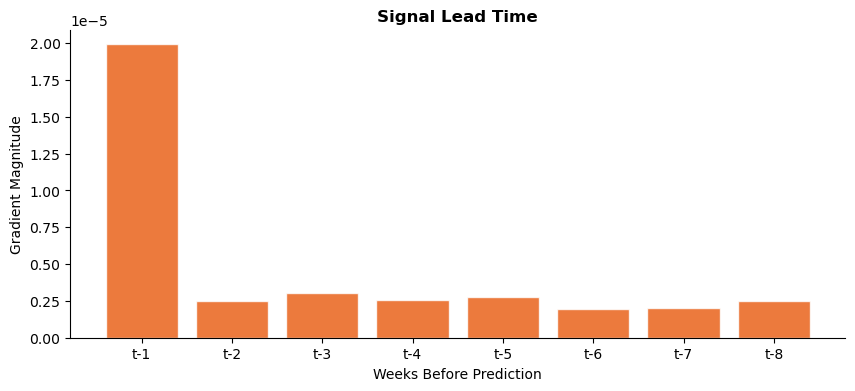

Peak signal: t-1 weeks


In [48]:
# Temporal Signal: Lead Time
model.eval()
temp_imp = np.zeros(LOOKBACK)
n_b = 0
for xb, yb in test_dl:
    xb = xb.to(device).requires_grad_(True)
    model(xb).sum().backward()
    temp_imp += xb.grad.abs().mean(dim=-1).mean(dim=0).cpu().numpy()
    n_b += 1
temp_imp /= n_b

fig, ax = plt.subplots(figsize=(10, 4))
weeks_ago = list(range(LOOKBACK, 0, -1))
ax.bar(weeks_ago, temp_imp, color='#E8590C', alpha=0.8, edgecolor='white')
ax.set_xlabel('Weeks Before Prediction')
ax.set_ylabel('Gradient Magnitude')
ax.set_title('Signal Lead Time', fontweight='bold')
ax.set_xticks(weeks_ago)
ax.set_xticklabels([f't-{w}' for w in weeks_ago])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.show()

peak = weeks_ago[np.argmax(temp_imp)]
print(f'Peak signal: t-{peak} weeks')

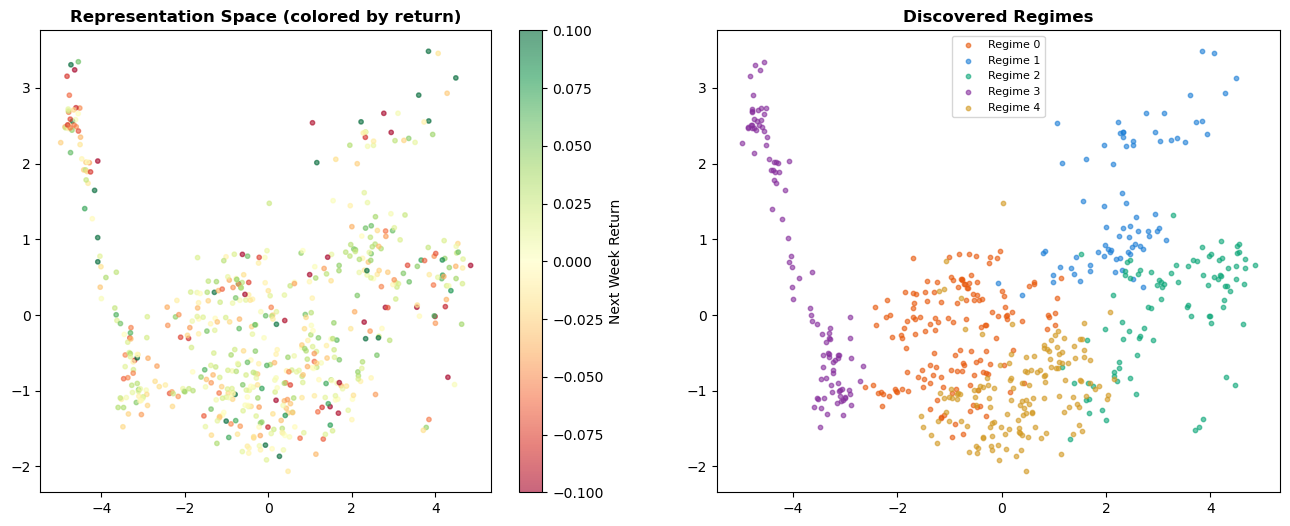

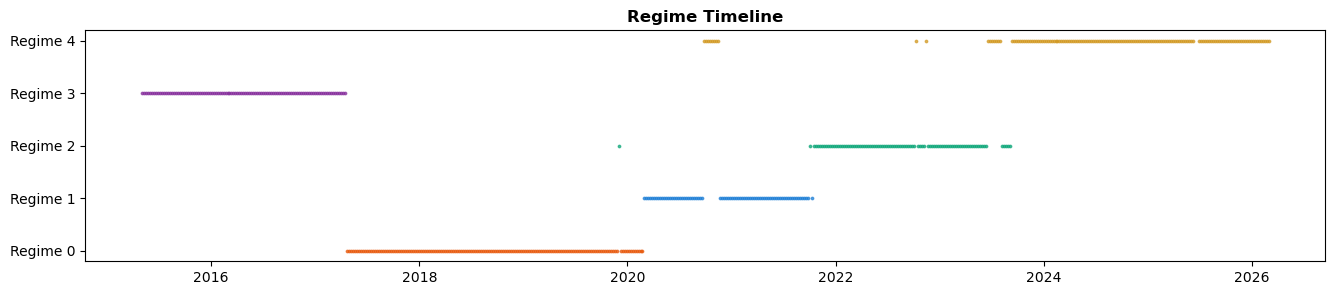

Regime stats:
  Regime 0: 148 weeks | avg return: +0.0009 | % up: 55%
  Regime 1:  76 weeks | avg return: +0.0087 | % up: 62%
  Regime 2:  92 weeks | avg return: +0.0017 | % up: 57%
  Regime 3: 103 weeks | avg return: -0.0031 | % up: 48%
  Regime 4: 145 weeks | avg return: +0.0028 | % up: 54%


In [49]:
# Regime Discovery
from sklearn.cluster import KMeans

model.eval()
reps, rep_weeks = [], []
for i in range(LOOKBACK, len(X_combined)):
    x = torch.FloatTensor(X_combined[i-LOOKBACK:i]).unsqueeze(0).to(device)
    with torch.no_grad():
        h = model.pos(model.encoder(x))
        h = model.transformer(h)
        reps.append(h[:, -1, :].cpu().numpy().flatten())
    rep_weeks.append(weeks_all[i])

reps = np.array(reps)
rep_weeks = np.array(rep_weeks)
rep_returns = y_all[LOOKBACK:LOOKBACK+len(reps)]

# PCA on representations for visualization
from sklearn.decomposition import PCA as PCA2
r2d = PCA2(n_components=2).fit_transform(reps)
clusters = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(reps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sc = ax1.scatter(r2d[:, 0], r2d[:, 1], c=rep_returns, cmap='RdYlGn', s=10, alpha=0.6, vmin=-0.1, vmax=0.1)
plt.colorbar(sc, ax=ax1, label='Next Week Return')
ax1.set_title('Representation Space (colored by return)', fontweight='bold')

cc = ['#E8590C', '#1C7ED6', '#0CA678', '#862E9C', '#D29922']
for c in range(5):
    m = clusters == c
    ax2.scatter(r2d[m, 0], r2d[m, 1], c=cc[c], s=10, alpha=0.6, label=f'Regime {c}')
ax2.legend(fontsize=8)
ax2.set_title('Discovered Regimes', fontweight='bold')
plt.show()

fig, ax = plt.subplots(figsize=(16, 3))
for c in range(5):
    m = clusters == c
    ax.scatter(rep_weeks[m], [c]*m.sum(), c=cc[c], s=3, alpha=0.7)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Regime {c}' for c in range(5)])
ax.set_title('Regime Timeline', fontweight='bold')
plt.show()

print('Regime stats:')
for c in range(5):
    m = clusters == c
    r = rep_returns[m]
    print(f'  Regime {c}: {m.sum():>3d} weeks | avg return: {r.mean():+.4f} | % up: {(r>0).mean():.0%}')

NEWS REGIMES vs PRICE CHANGE-POINT REGIMES
════════════════════════════════════════════════════════════
Method: Kernel Change Point Detection (RBF) on Brent price
Breakpoints found at indices: [127, 250, 301, 486]
Corresponding dates: ['2017-10', '2020-02', '2021-01', '2024-08']

Adjusted Rand Index: 0.5608
→ STRONG agreement

OVERLAP MATRIX (rows=News regime, cols=Price segment)
──────────────────────────────────────────────────
                 Seg 0     Seg 1     Seg 2     Seg 3     Seg 4
      News 0        24       122         2         0         0
      News 1         0         0        41        35         0
      News 2         0         1         0        91         0
      News 3       103         0         0         0         0
      News 4         0         0         8        59        78



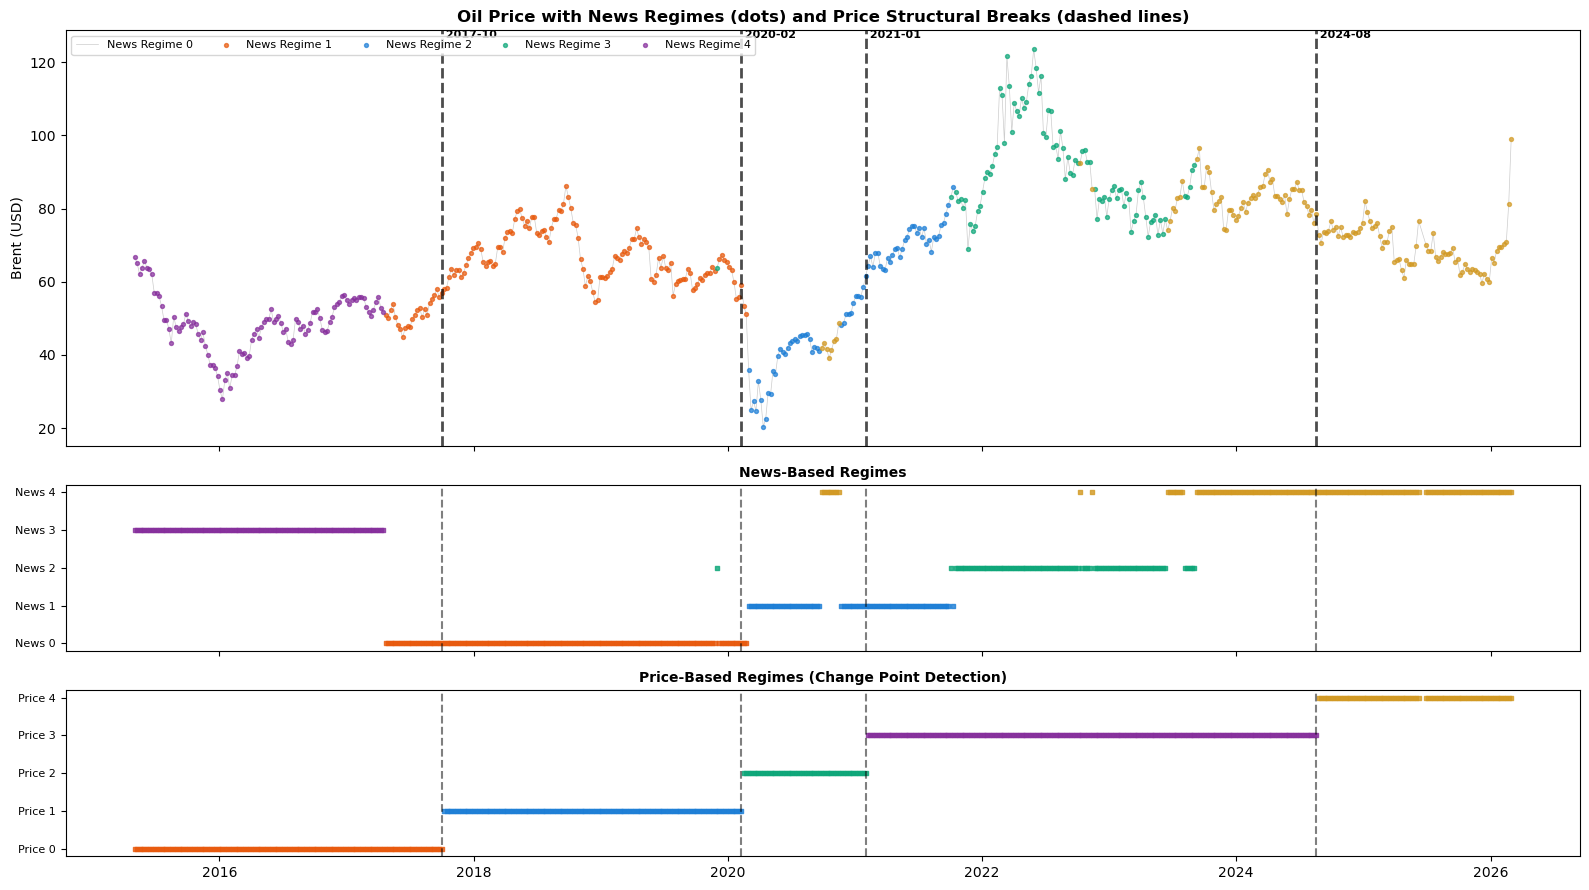

PRICE SEGMENT STATS:
  Segment 0: 127 weeks | $ 49.2 avg | ret: -0.0016 | up: 50% | 2015-05~2017-10
  Segment 1: 123 weeks | $ 67.0 avg | ret: +0.0014 | up: 56% | 2017-10~2020-02
  Segment 2:  51 weeks | $ 42.3 avg | ret: +0.0074 | up: 59% | 2020-02~2021-01
  Segment 3: 185 weeks | $ 84.5 avg | ret: +0.0023 | up: 57% | 2021-02~2024-08
  Segment 4:  78 weeks | $ 69.8 avg | ret: +0.0035 | up: 51% | 2024-08~2026-03

NEWS REGIME STATS:
  Regime  0: 148 weeks | $ 64.3 avg | ret: +0.0009 | up: 55% | 2017-04~2020-02
  Regime  1:  76 weeks | $ 55.2 avg | ret: +0.0087 | up: 62% | 2020-03~2021-10
  Regime  2:  92 weeks | $ 90.5 avg | ret: +0.0017 | up: 57% | 2019-12~2023-09
  Regime  3: 103 weeks | $ 48.7 avg | ret: -0.0031 | up: 48% | 2015-05~2017-04
  Regime  4: 145 weeks | $ 73.7 avg | ret: +0.0028 | up: 54% | 2020-09~2026-03


In [57]:
# ═══════════════════════════════════════════════════════
# Regime Validation: Change Point Detection on Price Data
# ═══════════════════════════════════════════════════════
!pip install ruptures -q

import ruptures as rpt
from sklearn.metrics import adjusted_rand_score

regime_weeks = rep_weeks
news_clusters = clusters
cc = ['#E8590C', '#1C7ED6', '#0CA678', '#862E9C', '#D29922']

# Build price series aligned to regime weeks
price_series = []
for w in regime_weeks:
    row = dataset[dataset['week'] == w]
    if len(row) > 0:
        price_series.append(row['brent_close'].values[0])
    else:
        idx = np.argmin(np.abs(dataset['week'].values.astype('datetime64[ns]') - np.datetime64(w)))
        price_series.append(dataset.iloc[idx]['brent_close'])

price_series = np.array(price_series)

# ── Change Point Detection ──
# Find 4 breakpoints → 5 segments (to match 5 news regimes)
# Pelt with rbf kernel — detects shifts in mean AND variance
algo = rpt.KernelCPD(kernel="rbf", min_size=20).fit(price_series)
breakpoints = algo.predict(n_bkps=4)

# Convert breakpoints to regime labels
price_regimes = np.zeros(len(price_series), dtype=int)
prev = 0
for i, bp in enumerate(breakpoints):
    price_regimes[prev:bp] = i
    prev = bp

# ── ARI: news regimes vs price change-point regimes ──
ari = adjusted_rand_score(news_clusters, price_regimes)

print('NEWS REGIMES vs PRICE CHANGE-POINT REGIMES')
print('═' * 60)
print(f'Method: Kernel Change Point Detection (RBF) on Brent price')
print(f'Breakpoints found at indices: {breakpoints[:-1]}')
bp_weeks = [regime_weeks[bp-1] for bp in breakpoints[:-1]]
print(f'Corresponding dates: {[str(w)[:7] for w in bp_weeks]}')
print(f'\nAdjusted Rand Index: {ari:.4f}')
if ari > 0.4:
    print(f'→ STRONG agreement')
elif ari > 0.2:
    print(f'→ MODERATE agreement')
elif ari > 0.05:
    print(f'→ WEAK but above-chance')
print()

# ── Overlap matrix ──
n_news = len(set(news_clusters))
n_price = len(set(price_regimes))
print(f'OVERLAP MATRIX (rows=News regime, cols=Price segment)')
print('─' * 50)
print(f'{"":>12s}', end='')
for j in range(n_price):
    print(f'{"Seg "+str(j):>10s}', end='')
print()
for i in range(n_news):
    print(f'{"News "+str(i):>12s}', end='')
    for j in range(n_price):
        count = np.sum((news_clusters == i) & (price_regimes == j))
        print(f'{count:>10d}', end='')
    print()
print()

# ── Visualization: side-by-side comparison ──
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True,
                          gridspec_kw={'height_ratios': [2.5, 1, 1]})

# 1. Price chart with BOTH regime colorings
ax = axes[0]
ax.plot(regime_weeks, price_series, color='gray', linewidth=0.5, alpha=0.4, zorder=1)

# Color by news regime
for c in range(5):
    m = news_clusters == c
    ax.scatter(regime_weeks[m], price_series[m], c=cc[c], s=8, alpha=0.7, zorder=3)

# Mark price change points with vertical lines
for bp in breakpoints[:-1]:
    ax.axvline(regime_weeks[bp-1], color='black', linewidth=2, linestyle='--', alpha=0.7, zorder=4)
    ax.text(regime_weeks[bp-1], ax.get_ylim()[1] if len(ax.get_lines()) > 0 else price_series.max(),
            f' {str(regime_weeks[bp-1])[:7]}', fontsize=8, fontweight='bold', va='top')

ax.set_ylabel('Brent (USD)')
ax.set_title('Oil Price with News Regimes (dots) and Price Structural Breaks (dashed lines)', fontweight='bold')
ax.legend([f'News Regime {c}' for c in range(5)], fontsize=8, ncol=5, loc='upper left')

# 2. News regime timeline
ax = axes[1]
for c in range(5):
    m = news_clusters == c
    ax.scatter(regime_weeks[m], [c]*m.sum(), c=cc[c], s=6, alpha=0.8, marker='s')
for bp in breakpoints[:-1]:
    ax.axvline(regime_weeks[bp-1], color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.set_yticks(range(5))
ax.set_yticklabels([f'News {c}' for c in range(5)], fontsize=8)
ax.set_title('News-Based Regimes', fontweight='bold', fontsize=10)

# 3. Price change-point regime timeline
ax = axes[2]
for c in range(n_price):
    m = price_regimes == c
    ax.scatter(regime_weeks[m], [c]*m.sum(), c=cc[c], s=6, alpha=0.8, marker='s')
for bp in breakpoints[:-1]:
    ax.axvline(regime_weeks[bp-1], color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.set_yticks(range(n_price))
ax.set_yticklabels([f'Price {c}' for c in range(n_price)], fontsize=8)
ax.set_title('Price-Based Regimes (Change Point Detection)', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ── Per-segment stats ──
print('PRICE SEGMENT STATS:')
for c in range(n_price):
    m = price_regimes == c
    r = rep_returns[m]
    weeks_in = regime_weeks[m]
    print(f'  Segment {c}: {m.sum():>3d} weeks | ${price_series[m].mean():>5.1f} avg | ret: {r.mean():+.4f} | up: {(r>0).mean():.0%} | {str(weeks_in.min())[:7]}~{str(weeks_in.max())[:7]}')

print(f'\nNEWS REGIME STATS:')
for c in range(5):
    m = news_clusters == c
    r = rep_returns[m]
    weeks_in = regime_weeks[m]
    print(f'  Regime  {c}: {m.sum():>3d} weeks | ${price_series[m].mean():>5.1f} avg | ret: {r.mean():+.4f} | up: {(r>0).mean():.0%} | {str(weeks_in.min())[:7]}~{str(weeks_in.max())[:7]}')

## 7. Model-Independent Statistical Analysis

The Transformer's R² is negative — its feature importance rankings are not trustworthy on their own.  
This section establishes **which GCAM dimensions are statistically associated with oil returns** using three methods that are completely independent of the deep learning model:

1. **Granger Causality** — does past news sentiment add predictive information beyond past returns alone?
2. **Spearman Correlation + FDR** — which dimensions co-move with oil returns, corrected for multiple testing?
3. **Event Study** — during extreme oil price weeks, which news dimensions spike?

All tests use the **original 2,962 GCAM dimensions** (pre-PCA) and are performed on the **training period only** (<2023) to avoid data leakage.

### 7.1 Granger Causality Test

Tests whether lagged values of a GCAM dimension improve prediction of oil returns beyond what lagged oil returns alone can do.  
Standard econometric test (Granger 1969). Significance after Bonferroni correction = defensible causal-precedence claim.

In [50]:
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Use training period only
train_df = dataset[dataset['week'] < pd.Timestamp('2023-01-01')].copy().reset_index(drop=True)
y_train = train_df['brent_return'].values
n_dims = len(feature_cols)
MAX_LAG = 4  # test up to 4 weeks of lag

print(f'Running Granger Causality on {n_dims} GCAM dimensions (train period, {len(train_df)} weeks)')
print(f'Max lag: {MAX_LAG} weeks')
print(f'Bonferroni threshold: p < {0.05/n_dims:.2e}')
print('─' * 70)

granger_results = []

for i, dim in enumerate(feature_cols):
    if (i+1) % 500 == 0:
        print(f'  ... {i+1}/{n_dims}')
    x = train_df[dim].values
    
    # Skip near-constant dimensions
    if np.std(x) < 1e-10:
        continue
    
    try:
        data = np.column_stack([y_train, x])
        res = grangercausalitytests(data, maxlag=MAX_LAG, verbose=False)
        # Take minimum p-value across all lags (most favorable)
        min_p = min(res[lag][0]['ssr_ftest'][1] for lag in range(1, MAX_LAG+1))
        best_lag = min(range(1, MAX_LAG+1), key=lambda l: res[l][0]['ssr_ftest'][1])
        f_stat = res[best_lag][0]['ssr_ftest'][0]
        granger_results.append({
            'dim': dim, 'p_value': min_p, 'f_stat': f_stat, 'best_lag': best_lag
        })
    except:
        continue

granger_df = pd.DataFrame(granger_results).sort_values('p_value')

# Bonferroni correction
bonferroni_alpha = 0.05 / n_dims
granger_df['bonferroni_sig'] = granger_df['p_value'] < bonferroni_alpha
granger_df['nominal_sig'] = granger_df['p_value'] < 0.05

# Add codebook labels
granger_df['label'] = granger_df['dim'].apply(
    lambda d: codebook[d]['dimension'] if d in codebook else '(unknown)'
)
granger_df['dictionary'] = granger_df['dim'].apply(
    lambda d: codebook[d]['dictionary'] if d in codebook else '(unknown)'
)

n_bonf = granger_df['bonferroni_sig'].sum()
n_nom = granger_df['nominal_sig'].sum()

print(f'\nRESULTS')
print(f'═' * 70)
print(f'Dimensions tested:              {len(granger_df)}')
print(f'Nominally significant (p<0.05): {n_nom} ({n_nom/len(granger_df):.1%})')
print(f'Bonferroni significant:         {n_bonf}')
print(f'\nExpected false positives at p<0.05 by chance: ~{len(granger_df)*0.05:.0f}')

print(f'\nTOP 20 Granger-Causal Dimensions (sorted by p-value):')
print(f'{"Rank":>4s} {"Dimension":>12s} {"p-value":>12s} {"F-stat":>8s} {"Lag":>4s} {"Sig":>5s}  Label')
print('─' * 90)
for rank, (_, row) in enumerate(granger_df.head(20).iterrows(), 1):
    sig_mark = '***' if row['bonferroni_sig'] else ('*' if row['nominal_sig'] else '')
    print(f'{rank:>4d} {row["dim"]:>12s} {row["p_value"]:>12.2e} {row["f_stat"]:>8.2f} {row["best_lag"]:>4d} {sig_mark:>5s}  {row["dictionary"]} → {row["label"]}')

if n_bonf > 0:
    print(f'\n🔬 {n_bonf} dimensions survive Bonferroni correction — these are statistically defensible.')
else:
    print(f'\nNo dimensions survive Bonferroni correction.')
    print(f'However, {n_nom} are nominally significant vs ~{len(granger_df)*0.05:.0f} expected by chance.')
    if n_nom > len(granger_df)*0.05 * 1.5:
        print(f'This is {n_nom/(len(granger_df)*0.05):.1f}x the chance rate — suggests real but weak signal.')


Running Granger Causality on 2963 GCAM dimensions (train period, 408 weeks)
Max lag: 4 weeks
Bonferroni threshold: p < 1.69e-05
──────────────────────────────────────────────────────────────────────
  ... 500/2963
  ... 1000/2963
  ... 1500/2963
  ... 2000/2963
  ... 2500/2963

RESULTS
══════════════════════════════════════════════════════════════════════
Dimensions tested:              2963
Nominally significant (p<0.05): 653 (22.0%)
Bonferroni significant:         0

Expected false positives at p<0.05 by chance: ~148

TOP 20 Granger-Causal Dimensions (sorted by p-value):
Rank    Dimension      p-value   F-stat  Lag   Sig  Label
──────────────────────────────────────────────────────────────────────────────────────────
   1       c29.40     2.83e-04     8.34    2     *  Regressive Imagery Dictionary Russian Edition (Partial Vocab Expansion) → PRIMARY/ICARIAN_IM/HEIGHT
   2       c39.25     3.23e-04     6.36    3     *  Hogenraad's TIME Dictionary → Young Person
   3       c35.10     6.

### 7.2 Spearman Rank Correlation + FDR Correction

Spearman correlation captures monotonic (not just linear) relationships.  
Benjamini-Hochberg FDR controls the expected proportion of false discoveries among significant results — less conservative than Bonferroni, more appropriate for exploratory analysis.

Running Spearman correlation for 2963 dimensions...

RESULTS
══════════════════════════════════════════════════════════════════════
Dimensions tested:              2963
Nominally significant (p<0.05): 283 (9.6%)
FDR significant (BH q<0.05):    0
Expected false positives at p<0.05 by chance: ~148

TOP 20 Correlated Dimensions (sorted by |ρ|):
Rank    Dimension        ρ      p-value   FDR  Label
──────────────────────────────────────────────────────────────────────────────────────────
   1       c37.19  +0.2084     2.21e-05     *  Hogenraad's Motive Dictionary Spanish Version → PositiveAffectLw
   2       c37.15  +0.1869     1.47e-04     *  Hogenraad's Motive Dictionary Spanish Version → AffiliationGainH4
   3       c39.28  +0.1820     2.18e-04     *  Hogenraad's TIME Dictionary → Earliness
   4       c37.32  +0.1793     2.74e-04     *  Hogenraad's Motive Dictionary Spanish Version → Affiliation
   5      c18.241  +0.1695     5.84e-04     *  GDELT GKG Themes → GOV_REPATRIATION
   6      

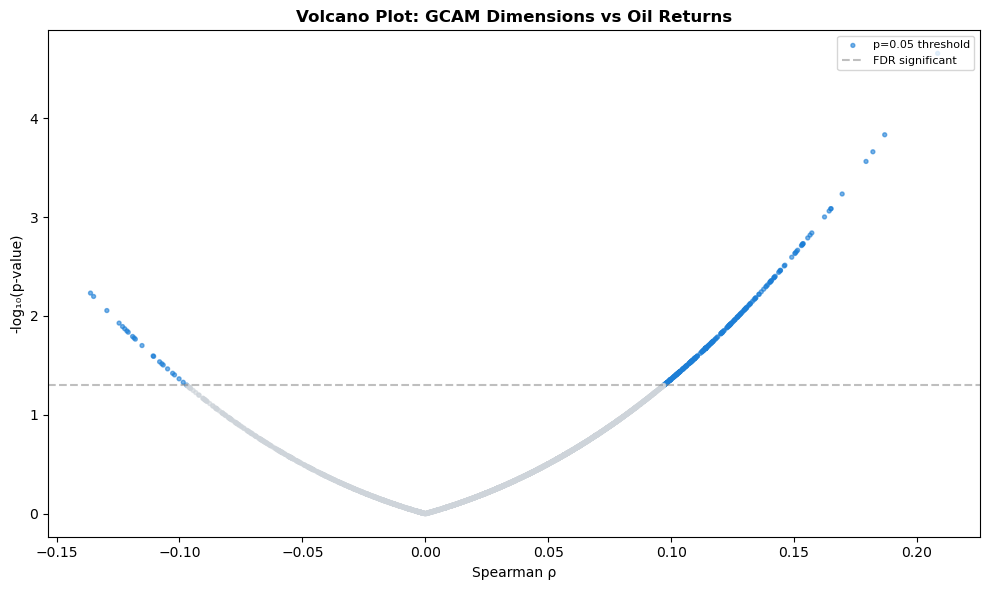

In [51]:
from scipy.stats import spearmanr

train_df = dataset[dataset['week'] < pd.Timestamp('2023-01-01')].copy().reset_index(drop=True)
y_train = train_df['brent_return'].values

print(f'Running Spearman correlation for {len(feature_cols)} dimensions...')

spearman_results = []
for dim in feature_cols:
    x = train_df[dim].values
    if np.std(x) < 1e-10:
        continue
    rho, p = spearmanr(x, y_train)
    spearman_results.append({'dim': dim, 'rho': rho, 'p_value': p, 'abs_rho': abs(rho)})

spearman_df = pd.DataFrame(spearman_results).sort_values('p_value')

# Benjamini-Hochberg FDR correction
n_tests = len(spearman_df)
spearman_df = spearman_df.reset_index(drop=True)
spearman_df['rank'] = range(1, n_tests + 1)
spearman_df['bh_threshold'] = (spearman_df['rank'] / n_tests) * 0.05
spearman_df['bh_significant'] = spearman_df['p_value'] <= spearman_df['bh_threshold']

# Find the largest rank where p <= threshold (BH procedure)
sig_mask = spearman_df['p_value'] <= spearman_df['bh_threshold']
if sig_mask.any():
    max_sig_rank = spearman_df.loc[sig_mask, 'rank'].max()
    spearman_df['fdr_significant'] = spearman_df['rank'] <= max_sig_rank
else:
    spearman_df['fdr_significant'] = False

# Also flag nominal significance
spearman_df['nominal_sig'] = spearman_df['p_value'] < 0.05

# Add labels
spearman_df['label'] = spearman_df['dim'].apply(
    lambda d: codebook[d]['dimension'] if d in codebook else '(unknown)'
)
spearman_df['dictionary'] = spearman_df['dim'].apply(
    lambda d: codebook[d]['dictionary'] if d in codebook else '(unknown)'
)

n_fdr = spearman_df['fdr_significant'].sum()
n_nom = spearman_df['nominal_sig'].sum()

print(f'\nRESULTS')
print(f'═' * 70)
print(f'Dimensions tested:              {n_tests}')
print(f'Nominally significant (p<0.05): {n_nom} ({n_nom/n_tests:.1%})')
print(f'FDR significant (BH q<0.05):    {n_fdr}')
print(f'Expected false positives at p<0.05 by chance: ~{n_tests*0.05:.0f}')

print(f'\nTOP 20 Correlated Dimensions (sorted by |ρ|):')
top_by_rho = spearman_df.sort_values('abs_rho', ascending=False).head(20)
print(f'{"Rank":>4s} {"Dimension":>12s} {"ρ":>8s} {"p-value":>12s} {"FDR":>5s}  Label')
print('─' * 90)
for rank, (_, row) in enumerate(top_by_rho.iterrows(), 1):
    sig_mark = '**' if row['fdr_significant'] else ('*' if row['nominal_sig'] else '')
    print(f'{rank:>4d} {row["dim"]:>12s} {row["rho"]:>+8.4f} {row["p_value"]:>12.2e} {sig_mark:>5s}  {row["dictionary"]} → {row["label"]}')

# Direction breakdown
if n_nom > 0:
    nom_sig = spearman_df[spearman_df['nominal_sig']]
    n_pos = (nom_sig['rho'] > 0).sum()
    n_neg = (nom_sig['rho'] < 0).sum()
    print(f'\nAmong nominally significant: {n_pos} positive, {n_neg} negative correlations')

# Volcano plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(spearman_df['fdr_significant'], '#E8590C',
         np.where(spearman_df['nominal_sig'], '#1C7ED6', '#CED4DA'))
ax.scatter(spearman_df['rho'], -np.log10(spearman_df['p_value']),
           c=colors, s=8, alpha=0.6)
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', alpha=0.5, label='p=0.05')
ax.set_xlabel('Spearman ρ')
ax.set_ylabel('-log₁₀(p-value)')
ax.set_title('Volcano Plot: GCAM Dimensions vs Oil Returns', fontweight='bold')
ax.legend(['p=0.05 threshold', 'FDR significant', 'Nominally significant', 'Not significant'],
          fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()


### 7.3 Event Study: Extreme Oil Price Weeks

Identify the top/bottom 10% of oil return weeks, then measure which GCAM dimensions show abnormal values during these extreme periods.  
Uses z-score of dimension values in extreme weeks vs. normal weeks — no model involved.

Extreme week thresholds: crash ≤ -5.64%, rally ≥ +5.65%
Crash weeks: 41, Rally weeks: 41, Normal: 326
──────────────────────────────────────────────────────────────────────

TOP 15 DIMENSIONS DURING OIL CRASHES (bottom 10% weeks)
Rank    Dimension   Crash Z      p-value   Rally Z  Label
───────────────────────────────────────────────────────────────────────────────────────────────
   1       c9.365    +0.991    5.45e-05*     +1.220  Roget's Thesaurus 1911 Edition → CLASS III - RELATED TO MATTER/3.2 INORGANIC MATTER/3.2.3 IMPERFECT FLUIDS/365 UNCTUOUSNESS
   2      c18.172    +0.939    1.50e-04*     +1.173  GDELT GKG Themes → ENV_OIL
   3       c9.265    +0.884    1.25e-03*     +0.785  Roget's Thesaurus 1911 Edition → CLASS II - RELATED TO SPACE/2.3 FORM/2.3.3 SUPERFICIAL FORM/265 SMOOTHNESS
   4        c9.77    +0.857    2.57e-02*     +0.610  Roget's Thesaurus 1911 Edition → CLASS I - ABSTRACT RELATIONS/1.4 ORDER/1.4.3 COLLECTIVE ORDER/77 DISPERSION
   5       c23.22    -0.832    7.29e

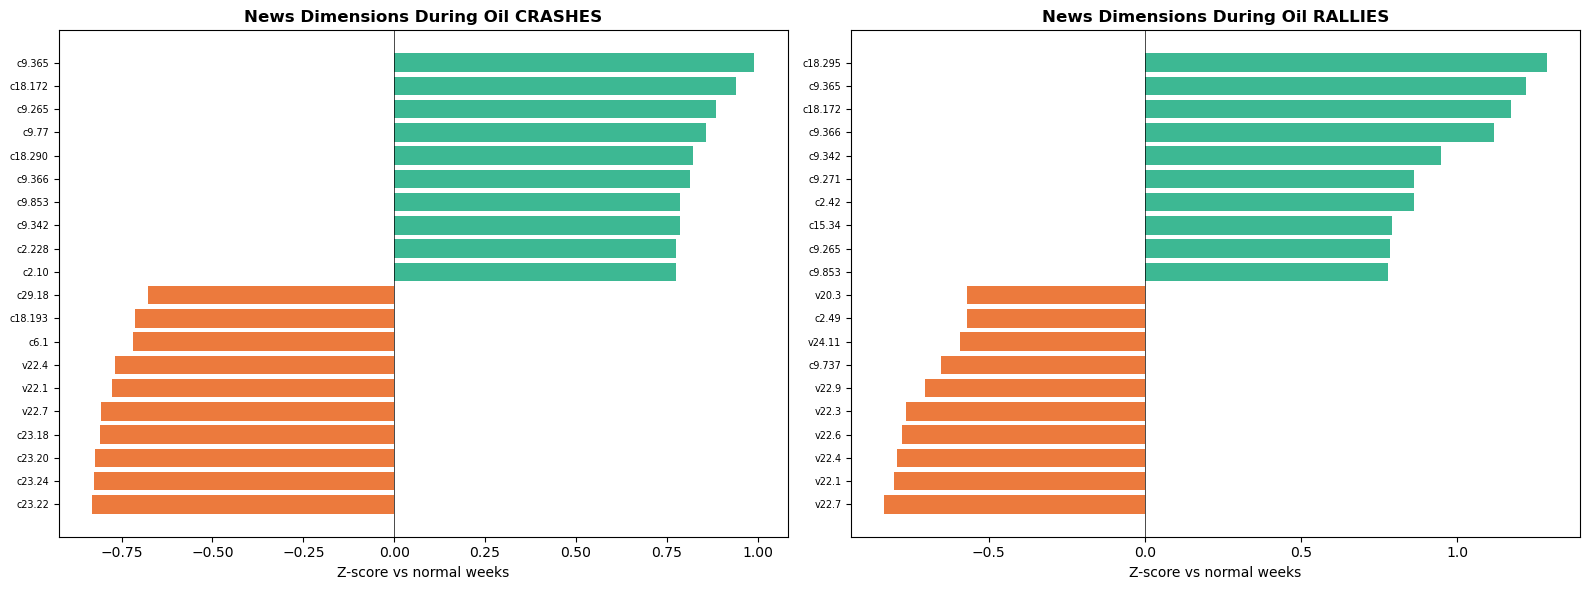

In [52]:
from scipy.stats import mannwhitneyu

train_df = dataset[dataset['week'] < pd.Timestamp('2023-01-01')].copy().reset_index(drop=True)
y_train = train_df['brent_return'].values

# Define extreme weeks (top/bottom 10%)
q10, q90 = np.percentile(y_train, [10, 90])
crash_mask = y_train <= q10
rally_mask = y_train >= q90
normal_mask = ~crash_mask & ~rally_mask

print(f'Extreme week thresholds: crash ≤ {q10:+.2%}, rally ≥ {q90:+.2%}')
print(f'Crash weeks: {crash_mask.sum()}, Rally weeks: {rally_mask.sum()}, Normal: {normal_mask.sum()}')
print('─' * 70)

event_results = []

for dim in feature_cols:
    x = train_df[dim].values
    if np.std(x) < 1e-10:
        continue
    
    x_normal = x[normal_mask]
    x_crash = x[crash_mask]
    x_rally = x[rally_mask]
    
    # Z-score: how abnormal is the dimension during extreme weeks?
    mu, sigma = x_normal.mean(), x_normal.std()
    if sigma < 1e-10:
        continue
    
    crash_z = (x_crash.mean() - mu) / sigma
    rally_z = (x_rally.mean() - mu) / sigma
    
    # Mann-Whitney U test (non-parametric) for crash vs normal
    try:
        _, p_crash = mannwhitneyu(x_crash, x_normal, alternative='two-sided')
        _, p_rally = mannwhitneyu(x_rally, x_normal, alternative='two-sided')
    except:
        continue
    
    event_results.append({
        'dim': dim,
        'crash_z': crash_z, 'rally_z': rally_z,
        'p_crash': p_crash, 'p_rally': p_rally,
        'max_abs_z': max(abs(crash_z), abs(rally_z))
    })

event_df = pd.DataFrame(event_results)

# Add labels
event_df['label'] = event_df['dim'].apply(
    lambda d: codebook[d]['dimension'] if d in codebook else '(unknown)'
)
event_df['dictionary'] = event_df['dim'].apply(
    lambda d: codebook[d]['dictionary'] if d in codebook else '(unknown)'
)

# Top dimensions during CRASHES
crash_top = event_df.sort_values('crash_z', key=abs, ascending=False).head(15)
print(f'\nTOP 15 DIMENSIONS DURING OIL CRASHES (bottom 10% weeks)')
print(f'{"Rank":>4s} {"Dimension":>12s} {"Crash Z":>9s} {"p-value":>12s} {"Rally Z":>9s}  Label')
print('─' * 95)
for rank, (_, row) in enumerate(crash_top.iterrows(), 1):
    sig = '*' if row['p_crash'] < 0.05 else ''
    print(f'{rank:>4d} {row["dim"]:>12s} {row["crash_z"]:>+9.3f} {row["p_crash"]:>11.2e}{sig}  {row["rally_z"]:>+9.3f}  {row["dictionary"]} → {row["label"]}')

# Top dimensions during RALLIES
rally_top = event_df.sort_values('rally_z', key=abs, ascending=False).head(15)
print(f'\nTOP 15 DIMENSIONS DURING OIL RALLIES (top 10% weeks)')
print(f'{"Rank":>4s} {"Dimension":>12s} {"Rally Z":>9s} {"p-value":>12s} {"Crash Z":>9s}  Label')
print('─' * 95)
for rank, (_, row) in enumerate(rally_top.iterrows(), 1):
    sig = '*' if row['p_rally'] < 0.05 else ''
    print(f'{rank:>4d} {row["dim"]:>12s} {row["rally_z"]:>+9.3f} {row["p_rally"]:>11.2e}{sig}  {row["crash_z"]:>+9.3f}  {row["dictionary"]} → {row["label"]}')

# Visualization: top 10 crash + rally dimensions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

crash_plot = event_df.nlargest(10, 'crash_z', 'all')[['dim', 'crash_z', 'label']].reset_index(drop=True)
crash_plot_neg = event_df.nsmallest(10, 'crash_z')[['dim', 'crash_z', 'label']].reset_index(drop=True)
crash_both = pd.concat([crash_plot_neg, crash_plot]).sort_values('crash_z')
colors_crash = ['#E8590C' if z < 0 else '#0CA678' for z in crash_both['crash_z']]
ax1.barh(range(len(crash_both)), crash_both['crash_z'], color=colors_crash, alpha=0.8)
ax1.set_yticks(range(len(crash_both)))
ax1.set_yticklabels([f"{r['dim']}" for _, r in crash_both.iterrows()], fontsize=7)
ax1.set_xlabel('Z-score vs normal weeks')
ax1.set_title('News Dimensions During Oil CRASHES', fontweight='bold')
ax1.axvline(0, color='black', linewidth=0.5)

rally_plot = event_df.nlargest(10, 'rally_z', 'all')[['dim', 'rally_z', 'label']].reset_index(drop=True)
rally_plot_neg = event_df.nsmallest(10, 'rally_z')[['dim', 'rally_z', 'label']].reset_index(drop=True)
rally_both = pd.concat([rally_plot_neg, rally_plot]).sort_values('rally_z')
colors_rally = ['#E8590C' if z < 0 else '#0CA678' for z in rally_both['rally_z']]
ax2.barh(range(len(rally_both)), rally_both['rally_z'], color=colors_rally, alpha=0.8)
ax2.set_yticks(range(len(rally_both)))
ax2.set_yticklabels([f"{r['dim']}" for _, r in rally_both.iterrows()], fontsize=7)
ax2.set_xlabel('Z-score vs normal weeks')
ax2.set_title('News Dimensions During Oil RALLIES', fontweight='bold')
ax2.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()
